需求：北京明天的天气怎么样？上海呢？ （通过两次对话实现）

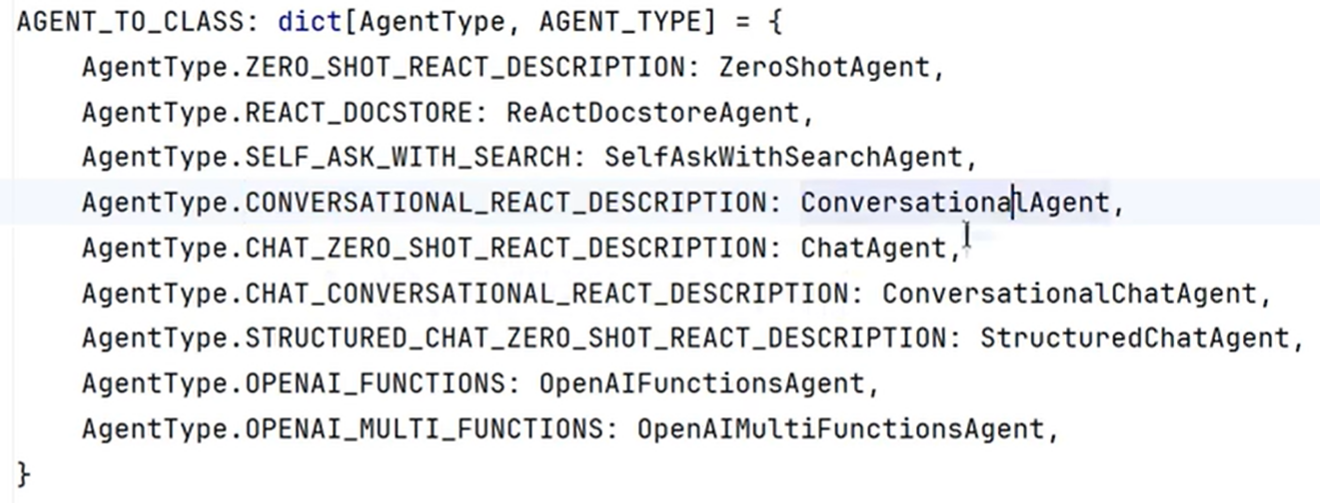

以ReAct方式为例

In [2]:
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.agents import AgentType, initialize_agent
from langchain_classic.tools import Tool
from langchain_community.tools import TavilySearchResults
from langchain_openai import ChatOpenAI
import os
import dotenv
dotenv.load_dotenv()

# 读取配置文件
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# 获取Tavily搜索工具实例
search = TavilySearchResults(max_results = 3)
search_tool = Tool(
    func = search.run,
    name = "search",
    description = "用于检索互联网上的信息",
)
# 获取大模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)
# 获取记忆的实例:ConversationBufferMemory
memory = ConversationBufferMemory(
    return_messages= True,
    memory_key= "chat_history" # 必须设置memory_key的值为chat_history，因为提示词模版中使用的是chat_history，二者必须一致
)
# 创建agent示例
agent = AgentType.CONVERSATIONAL_REACT_DESCRIPTION
# 创建agentExecutor实例
agent_execute = initialize_agent(
    llm =llm,
    agent = agent,
    tools = [search_tool],
    verbose = True,
    memory = memory,
)
# 通过agentExecutor调用invoke()，并得到响应
result = agent_execute.invoke("查询西安今天天气情况")
# 处理响应数据
print(result)



> Entering new AgentExecutor chain...
```
Thought: Do I need to use a tool? Yes
Action: search
Action Input: 西安今天天气情况
```
Observation: [{'title': '西安-天气预报 - 中央气象台', 'url': 'https://www.nmc.cn/publish/forecast/ASN/xian.html', 'content': '+ 土壤水分监测\n  + 农业干旱综合监测\n  + 关键农时农事\n  + 农业气象周报\n  + 农业气象月报\n  + 生态气象监测评估\n  + 农业气象专报\n  + 作物发育期监测\n  + 农业气象灾害风险预警\n  + 国外农业气象月报\n 数值预报\n\n  + CMA全球天气模式\n  + CMA全球集合模式\n  + CMA区域模式\n  + CMA区域集合模式\n  + CMA台风模式\n  + 海浪模式\n\n1. 当前位置：首页\n2. 陕西省\n3. 西安天气预报\n\n省份：城市：\n\n日出\n\n西安\n\n日落\n\n降水量\n\n相对湿度\n\n体感温度\n\n雷达图\n\n24小时预报7天预报10天预报11-30天预报\n\n发布时间：03-23 12:00\n\n03/23   \n周一\n\n小雨\n\n无持续风向\n\n微风\n\n12℃\n\n7℃\n\n小雨\n\n无持续风向\n\n微风\n\n03/24   \n周二\n\n多云\n\n无持续风向\n\n微风\n\n18℃\n\n6℃\n\n多云\n\n无持续风向\n\n微风\n\n03/25   \n周三\n\n阴\n\n无持续风向\n\n微风\n\n20℃\n\n7℃\n\n阴\n\n无持续风向\n\n微风\n\n03/26   \n周四\n\n阴\n\n无持续风向\n\n微风\n\n17℃\n\n8℃\n\n多云\n\n无持续风向\n\n微风\n\n03/27   \n周五\n\n晴\n\n无持续风向\n\n微风\n\n21℃\n\n9℃\n\n阴\n\n无持续风向\n\n微风\n\n03/28   \n周六\n\n多云\n\n无持续风向\n\n微风\n\n21℃\n\n8℃\n\n阴\

In [3]:
result = agent_execute.invoke("上海呢？")
print(result)



> Entering new AgentExecutor chain...
```
Thought: Do I need to use a tool? Yes
Action: search
Action Input: 上海今天天气情况
```
Observation: [{'title': '上海-天气预报 - 中央气象台', 'url': 'https://www.nmc.cn/publish/forecast/ASH/shanghai.html', 'content': '+ 土壤水分监测\n  + 农业干旱综合监测\n  + 关键农时农事\n  + 农业气象周报\n  + 农业气象月报\n  + 生态气象监测评估\n  + 农业气象专报\n  + 作物发育期监测\n  + 农业气象灾害风险预警\n  + 国外农业气象月报\n 数值预报\n\n  + CMA全球天气模式\n  + CMA全球集合模式\n  + CMA区域模式\n  + CMA区域集合模式\n  + CMA台风模式\n  + 海浪模式\n\n1. 当前位置：首页\n2. 上海市\n3. 上海天气预报\n\n省份：城市：\n\n日出\n\n上海\n\n日落\n\n降水量\n\n相对湿度\n\n体感温度\n\n雷达图\n\n24小时预报7天预报10天预报11-30天预报\n\n发布时间：03-25 08:00\n\n03/25   \n周三\n\n多云\n\n西北风\n\n微风\n\n18℃\n\n10℃\n\n阴\n\n东风\n\n微风\n\n03/26   \n周四\n\n小雨\n\n东南风\n\n微风\n\n20℃\n\n11℃\n\n小雨\n\n东风\n\n微风\n\n03/27   \n周五\n\n阴\n\n东风\n\n微风\n\n20℃\n\n10℃\n\n阴\n\n东南风\n\n微风\n\n03/28   \n周六\n\n阴\n\n东南风\n\n微风\n\n22℃\n\n13℃\n\n小雨\n\n东南风\n\n微风\n\n03/29   \n周日\n\n小雨\n\n南风\n\n3~4级\n\n22℃\n\n14℃\n\n小雨\n\n东风\n\n微风\n\n03/30   \n周一\n\n中雨\n\n西北风\n\n3~4级\n\n21℃\n\n12℃\n\n小雨\n\n北风\n\n3~

function_call方式

In [11]:
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.agents import AgentType, initialize_agent
from langchain_classic.tools import Tool
from langchain_community.tools import TavilySearchResults
from langchain_openai import ChatOpenAI
import os
import dotenv
dotenv.load_dotenv()

# 读取配置文件
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# 获取Tavily搜索工具实例
search = TavilySearchResults(max_results = 3)
search_tool = Tool(
    func = search.run,
    name = "search",
    description = "用于检索互联网上的信息",
)
# 获取大模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)
# 获取记忆的实例:ConversationBufferMemory
memory = ConversationBufferMemory(
    return_messages= True,
    memory_key= "chat_history" # 必须设置memory_key的值为chat_history，因为提示词模版中使用的是chat_history，二者必须一致
)
# 创建agent示例
agent = AgentType.OPENAI_FUNCTIONS
# 创建agentExecutor实例
agent_execute = initialize_agent(
    llm =llm,
    agent = agent,
    tools = [search_tool],
    verbose = True,
    memory = memory,
)
# 通过agentExecutor调用invoke()，并得到响应
response = agent_execute.invoke({"input":"今天是周几"})
# 处理响应数据
print(response)



> Entering new AgentExecutor chain...


TypeError: langchain_core.language_models.chat_models.BaseChatModel.generate_prompt() got multiple values for keyword argument 'callbacks'